# Simulation — Realistic Scenarios

## Setup

In [ ]:

library(here)


here() starts at C:/Users/pablo/OneDrive/Github/cfa-power

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.

###############################################################################

This is semTools 0.5-8

All users of R (or SEM) are invited to submit functions or ideas for functions.

...


Attaching package: 'dplyr'

The following object is masked from 'package:MASS':

    select

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: SparseM

## Scenario A — Missing data (MCAR 10%)

Introduce 10% missing completeness at random (MCAR). This demonstrates the power cost of attrition / item non-response. For more complex missing data patterns (e.g., MAR, MNAR), you would need to specify a more detailed missing data mechanism (`miss` function in `simsem` package), but this serves as a baseline for the impact of missingness on power. We use FIML estimation to handle the missing data, which is a common approach in SEM.

In [ ]:

popmodel_miss <- cache_or_run("popmodel_miss", {
    sim(
        NULL,
        n = SEQ1,              # See the `SEQ1` object defined in helpers.R for the sample size sequence used in this scenario.
        pmMCAR = 0.10,
        analyzemodel,
        generate = popmodel,
        std.lv = TRUE,
        lavaanfun = "cfa",
        estimator = "ml",
        missing = "fiml",
        seed = SEED,
        multicore = TRUE
    )
})


In [ ]:

h1model_miss <- cache_or_run("h1model_miss", {
    sim(
        NULL,
        n = SEQ1,              # See the `SEQ1` object defined in helpers.R for the sample size sequence used in this scenario.
        pmMCAR = 0.10,
        analyzemodel,
        generate = h1model,
        std.lv = TRUE,
        lavaanfun = "cfa",
        estimator = "ml",
        missing = "fiml",
        seed = SEED,
        multicore = TRUE
    )
})


### Power curves for fit indices

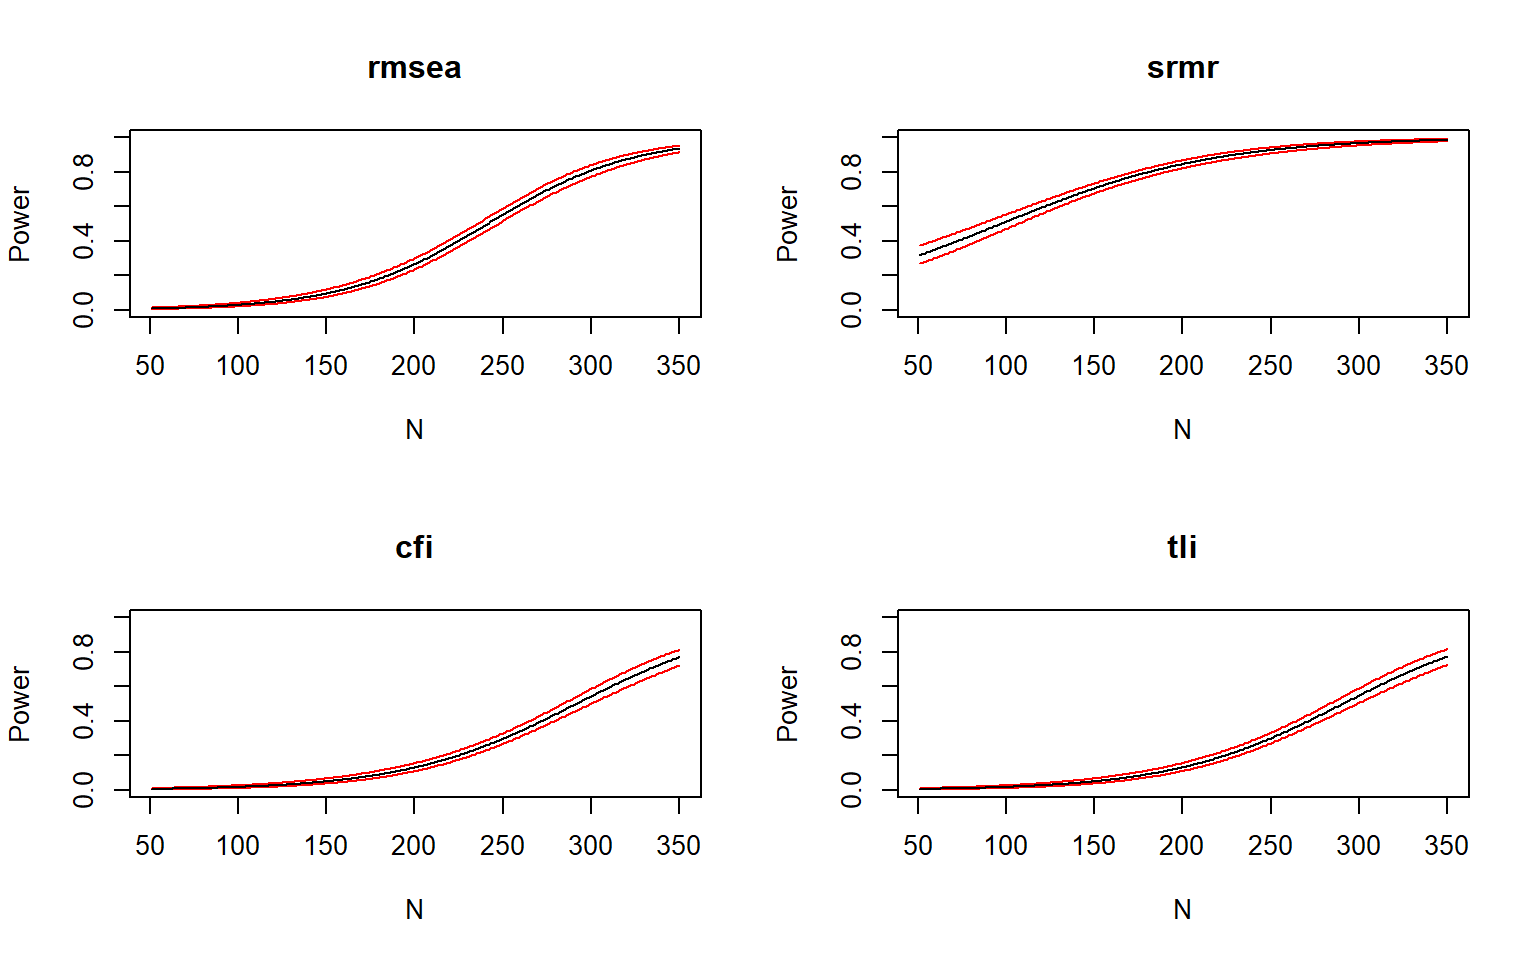

In [ ]:

plotPowerFit(
    h1model_miss,
    popmodel_miss,
    alpha = ALPHA,
    usedFit = FITS
)


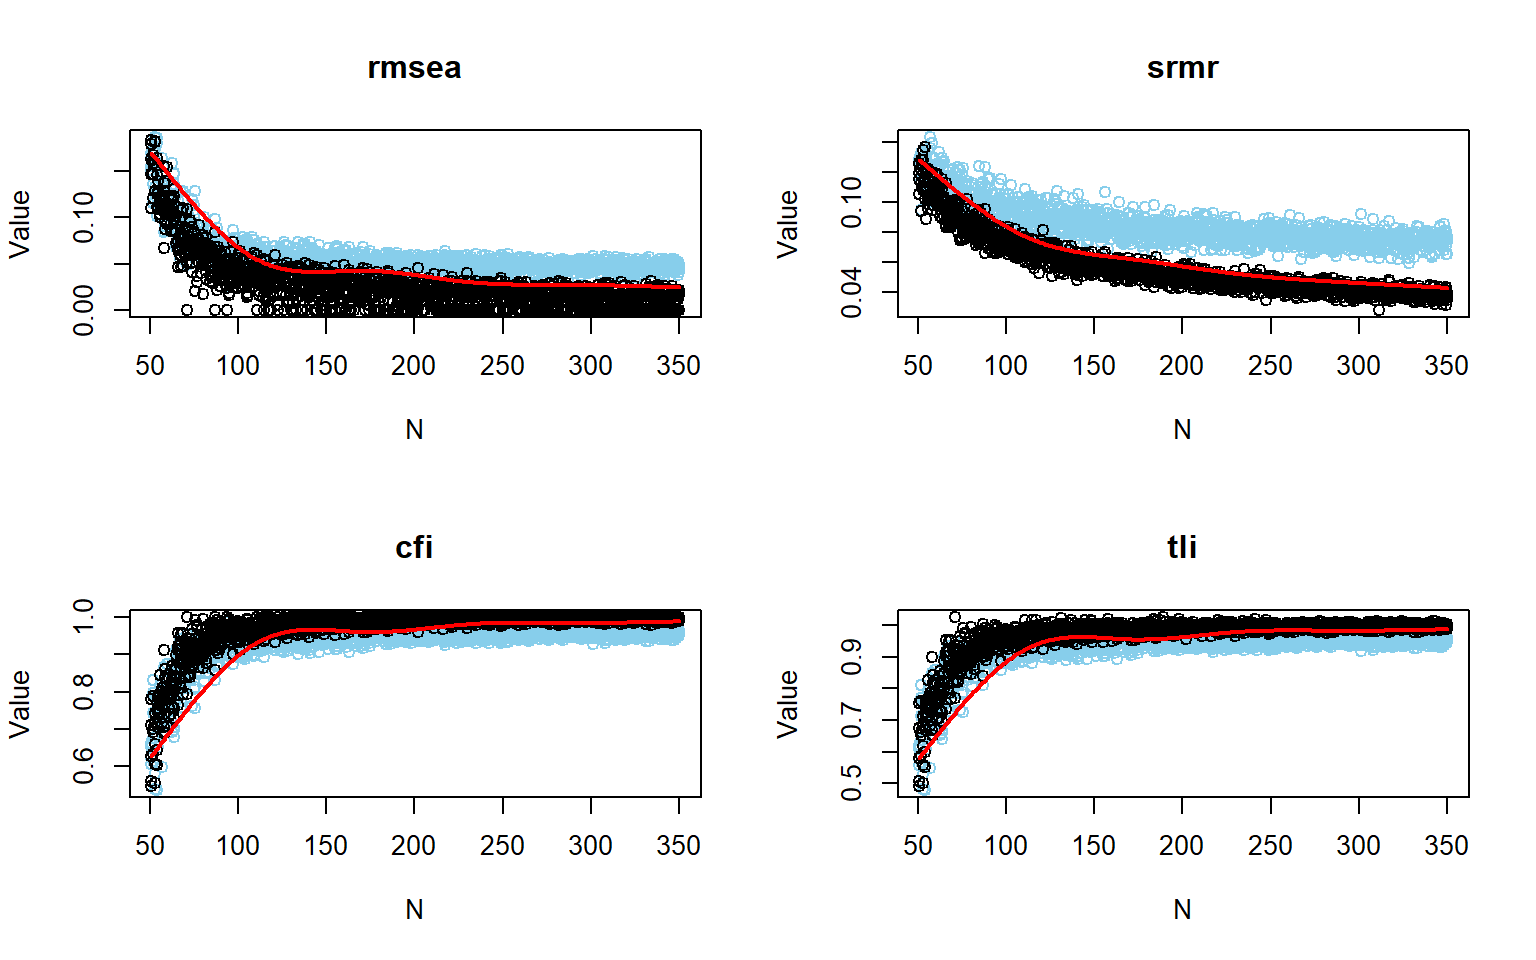

In [ ]:

plotPowerFit(
    h1model_miss,
    popmodel_miss,
    alpha = ALPHA,
    usedFit = FITS,
    logistic = FALSE
)


### Power cutoff values for fit indices

You extract the cutoff values for fit indices at a given alpha level and sample size to determine the threshold for acceptable fit under the null model. This allows you to see how stringent the fit criteria are at different sample sizes.

``` r

getPowerFit(
    h1model_miss,
    nullObject = popmodel_miss,
    alpha = ALPHA,
    nVal = 359,
    usedFit = FITS
)
```

        rmsea      srmr       cfi       tli 
    0.9471638 0.9869795 0.8018185 0.8057400 

``` r

getCutoff(
    popmodel_miss,
    alpha = ALPHA,
    nVal = 359,
    usedFit = FITS
)
```

           rmsea      srmr      cfi      tli
    1 0.01120342 0.0350943 1.007667 1.009877

## Scenario B — Non-normality

Generate data from the population model with normal distributions, then apply marginal transformations to introduce moderate non-normality (skewness ≈ 1.5, kurtosis ≈ 3). This simulates realistic conditions where psychological data often deviate from multivariate normality.

We use a custom data generation function that applies a power transformation to each variable after generation, combined with ML and MLR estimators to show the impact.

In [ ]:

popmodel_nnorm <- cache_or_run("popmodel_nnorm", {
    sim(
        NULL,
        n = SEQ1,             # See the `SEQ1` object defined in helpers.R for the sample size sequence used in this scenario.
        analyzemodel,
        generate = popmodel,
        indDist = dist,       # See the `dist` object defined in helpers.R for the range of skewness and kurtosis values.
        std.lv = TRUE,
        lavaanfun = "cfa",
        estimator = "mlr",
        seed = SEED,
        multicore = TRUE
    )
})


In [ ]:

h1model_nnorm <- cache_or_run("h1model_nnorm", {
    sim(
        NULL,
        n = SEQ1,             # See the `SEQ1` object defined in helpers.R for the sample size sequence used in this scenario.
        analyzemodel,
        generate = h1model,
        indDist = dist,       # See the `dist` object defined in helpers.R for the range of skewness and kurtosis values.
        std.lv = TRUE,
        lavaanfun = "cfa",
        estimator = "mlr",
        seed = SEED,
        multicore = TRUE
    )
})


### Power curves for fit indices

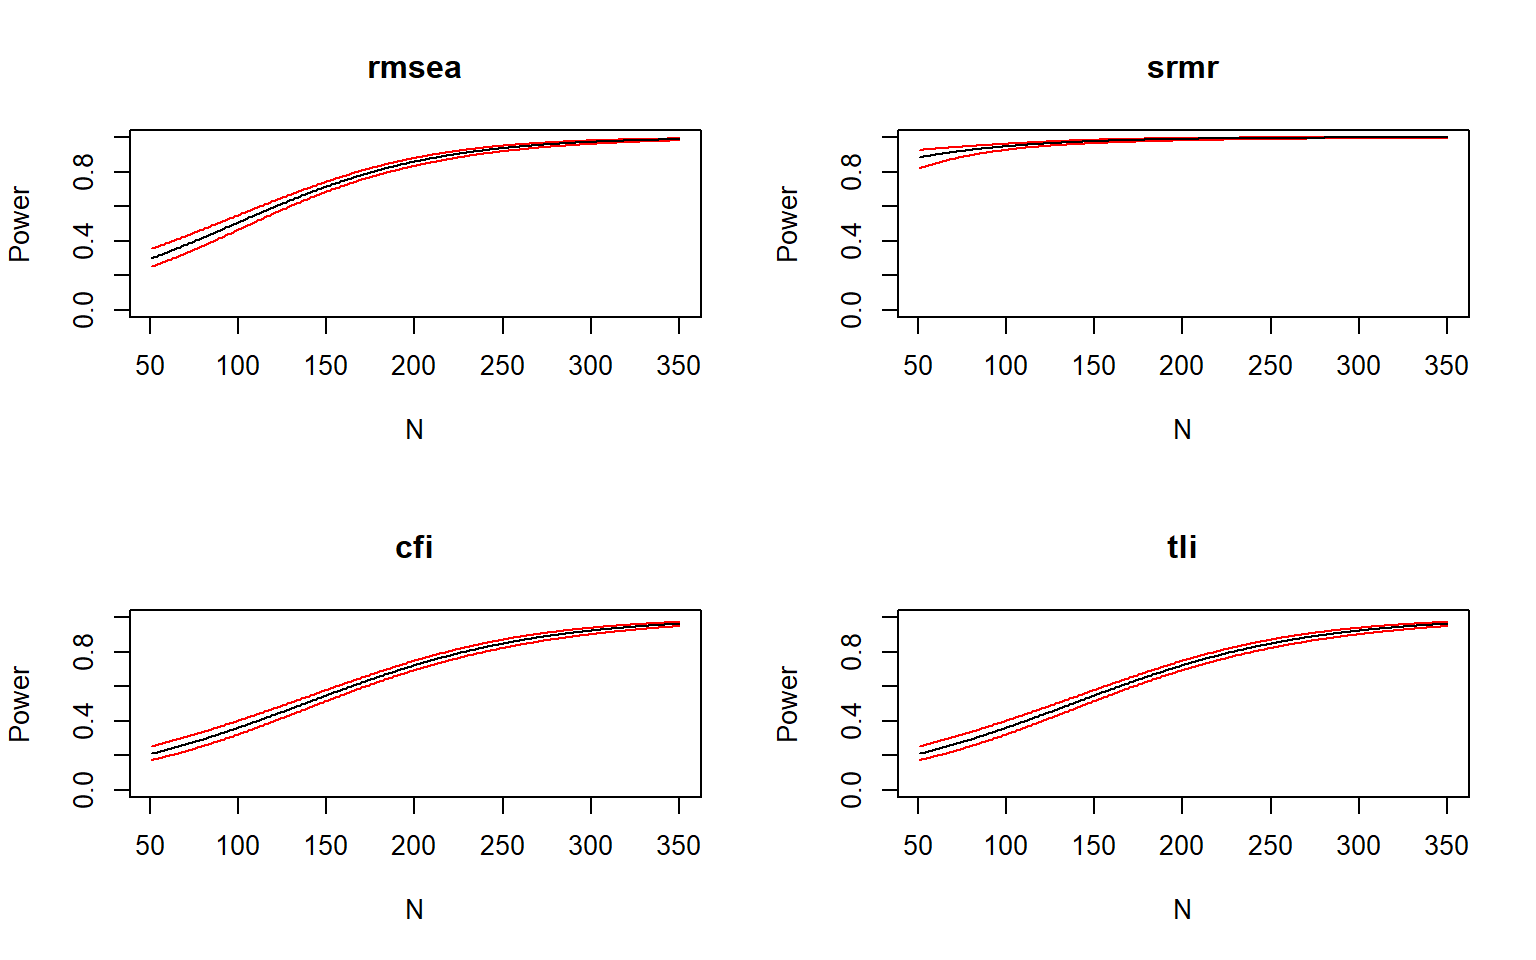

In [ ]:

plotPowerFit(
    h1model_nnorm,
    popmodel_nnorm,
    alpha = ALPHA,
    usedFit = FITS
)


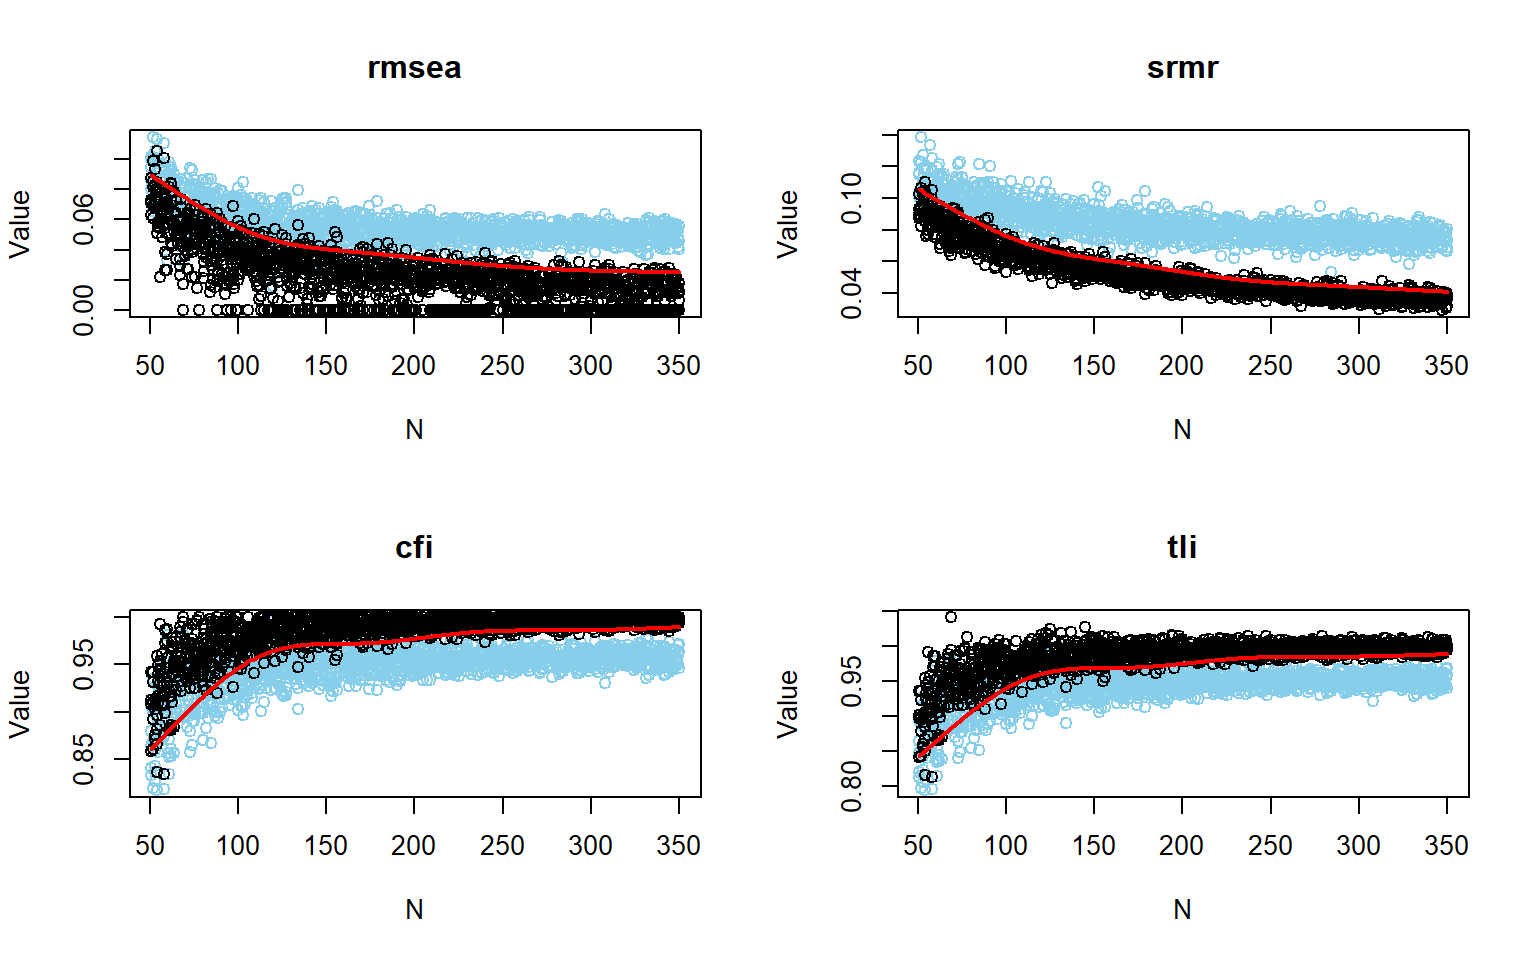

In [ ]:

plotPowerFit(
    h1model_nnorm,
    popmodel_nnorm,
    alpha = ALPHA,
    usedFit = FITS,
    logistic = FALSE
)


### Power cutoff values for fit indices

You extract the cutoff values for fit indices at a given alpha level and sample size to determine the threshold for acceptable fit under the null model. This allows you to see how stringent the fit criteria are at different sample sizes.

``` r

getPowerFit(
    h1model_nnorm,
    nullObject = popmodel_nnorm,
    alpha = ALPHA,
    nVal = 228,
    usedFit = FITS
)
```

        rmsea      srmr       cfi       tli 
    0.9099824 0.9942105 0.8003211 0.8003211 

``` r

getCutoff(
    popmodel_nnorm,
    alpha = ALPHA,
    nVal = 228,
    usedFit = FITS
)
```

           rmsea       srmr      cfi       tli
    1 0.03979016 0.05894574 0.964321 0.9598066

## Scenario C — Missing data + Non-normality

This scenario combines the challenges of missing data and non-normality, reflecting common issues in real-world datasets. We generate data with 10% MAR missingness and apply the same marginal transformations to introduce non-normality.

In [ ]:

popmodel_normiss <- cache_or_run("popmodel_normiss", {
    sim(
        NULL,
        n = SEQ2,             # See the `SEQ2` object defined in helpers.R for the sample size sequence used in this scenario.
        pmMCAR = 0.10,
        analyzemodel,
        generate = popmodel,
        indDist = dist,       # See the `dist` object defined in helpers.R for the range of skewness and kurtosis values.
        std.lv = TRUE,
        lavaanfun = "cfa",
        estimator = "mlr",
        missing = "fiml",
        seed = SEED,
        multicore = TRUE
    )
})


In [ ]:

h1model_normiss <- cache_or_run("h1model_normiss", {
    sim(
        NULL,
        n = SEQ2,             # See the `SEQ2` object defined in helpers.R for the sample size sequence used in this scenario.
        pmMCAR = 0.10,
        analyzemodel,
        generate = h1model,
        indDist = dist,       # See the `dist` object defined in helpers.R for the range of skewness and kurtosis values.
        std.lv = TRUE,
        lavaanfun = "cfa",
        estimator = "mlr",
        missing = "fiml",
        seed = SEED,
        multicore = TRUE
    )
})


### Power curves for fit indices

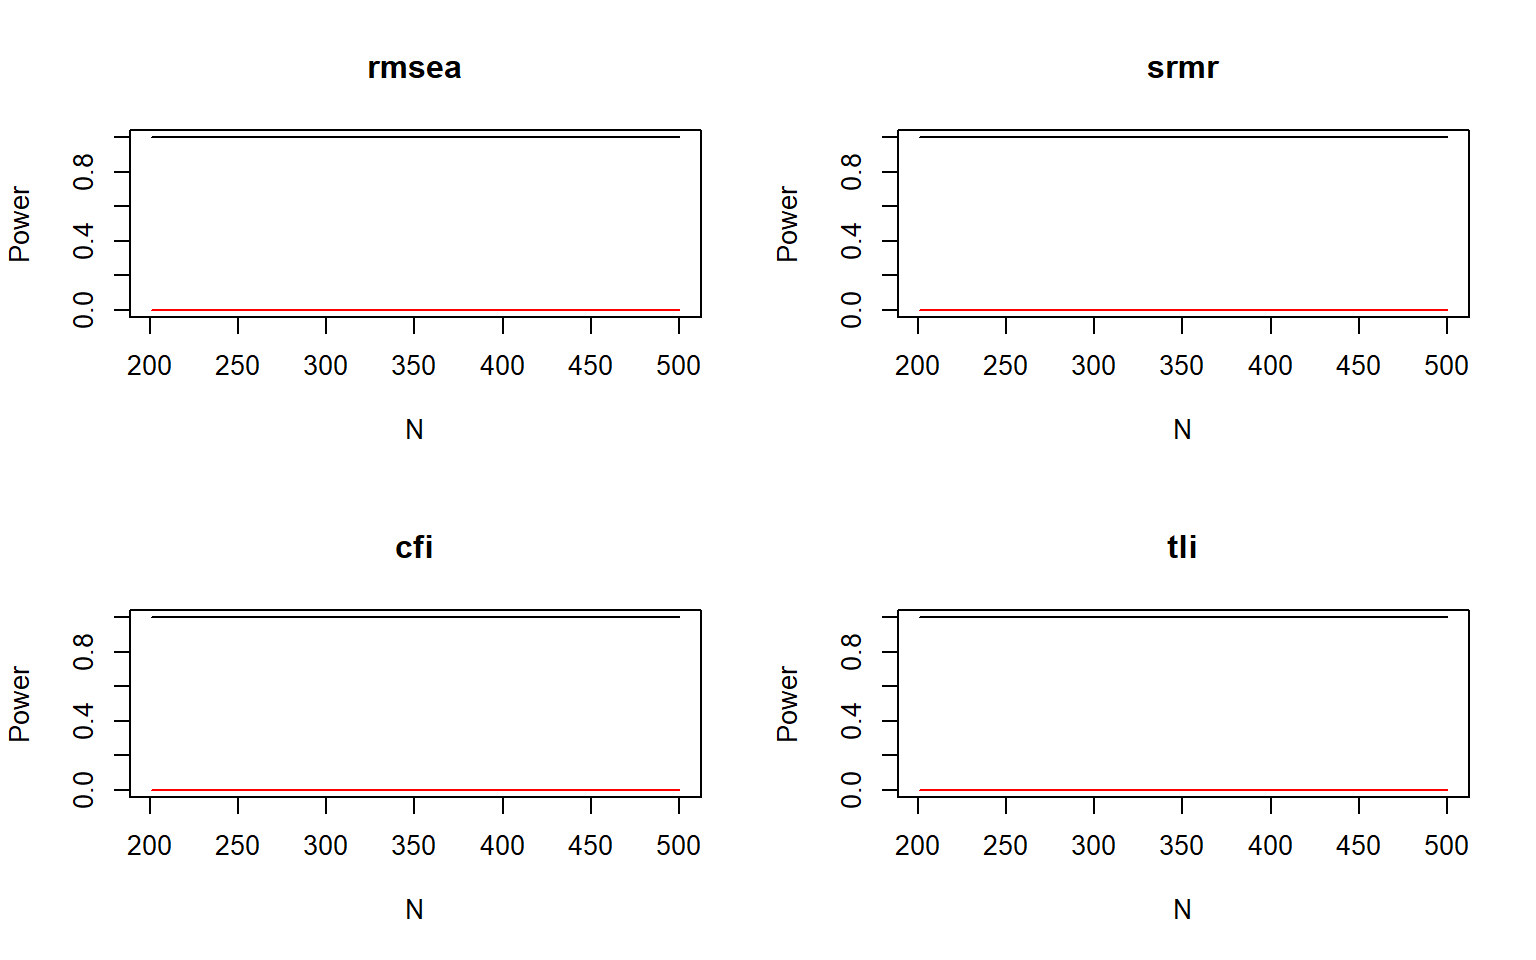

In [ ]:

plotPowerFit(
    h1model_normiss,
    popmodel_normiss,
    alpha = ALPHA,
    usedFit = FITS
)


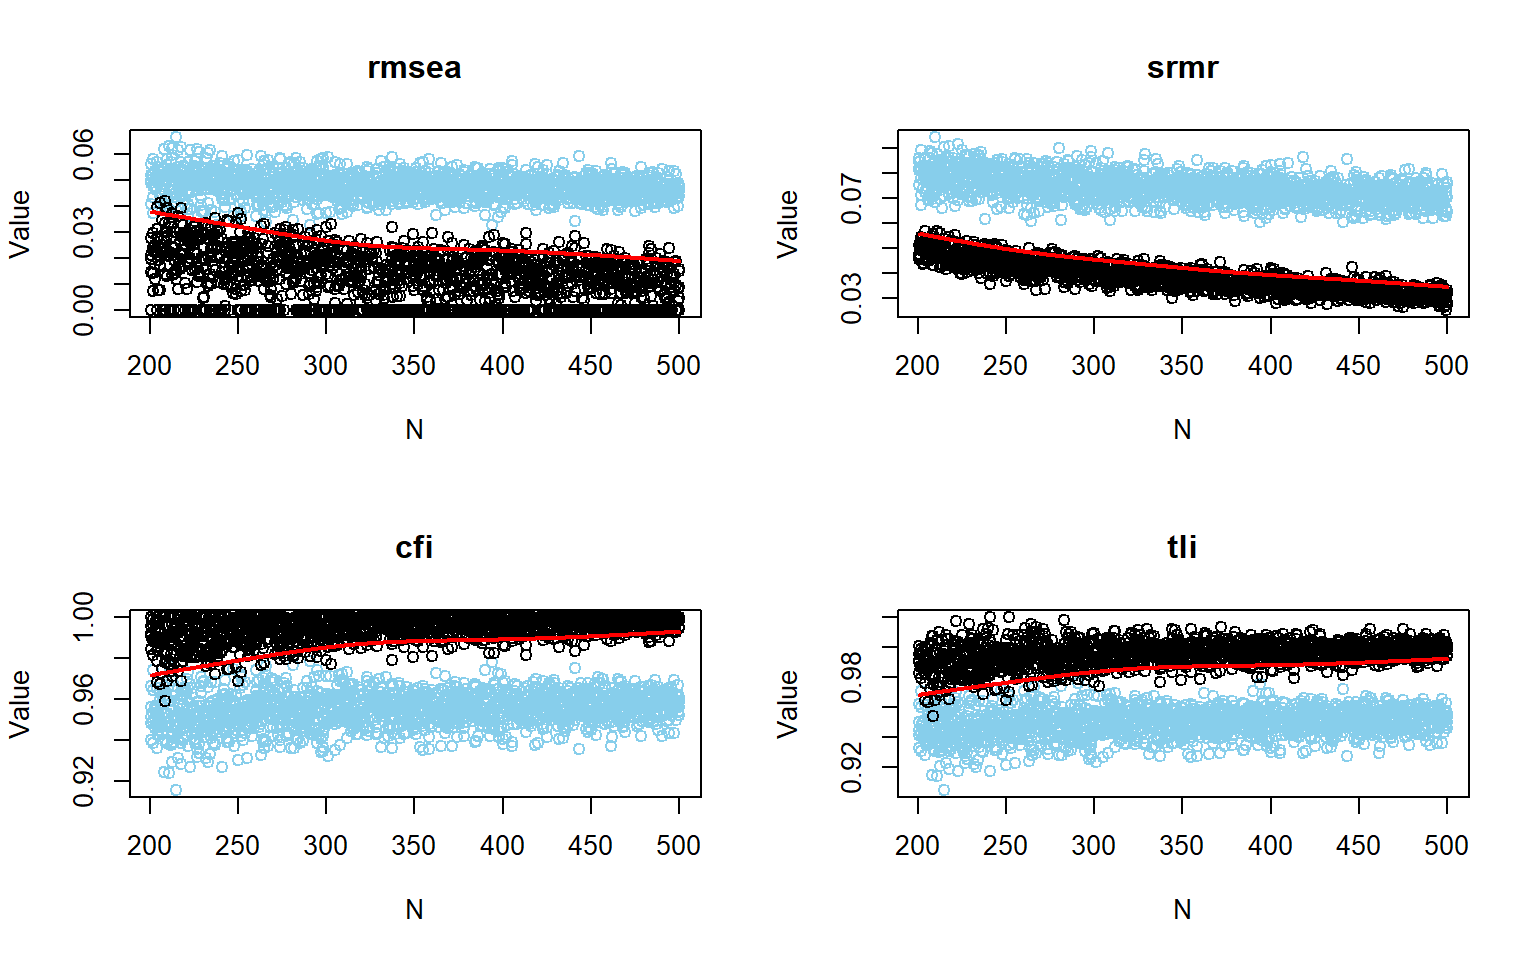

In [ ]:

plotPowerFit(
    h1model_normiss,
    popmodel_normiss,
    alpha = ALPHA,
    usedFit = FITS,
    logistic = FALSE
)


### Power cutoff values for fit indices

You extract the cutoff values for fit indices at a given alpha level and sample size to determine the threshold for acceptable fit under the null model. This allows you to see how stringent the fit criteria are at different sample sizes.

``` r

getPowerFit(
    h1model_normiss,
    nullObject = popmodel_normiss,
    alpha = ALPHA,
    nVal = 200,
    usedFit = FITS
)
```

    rmsea  srmr   cfi   tli 
        1     1     1     1 

``` r

getCutoff(
    popmodel_normiss,
    alpha = ALPHA,
    nVal = 200,
    usedFit = FITS
)
```

           rmsea       srmr       cfi       tli
    1 0.03379438 0.05324447 0.9774917 0.9746437